# Google Landmarks Dataset v2 — Metadata Analysis

Downloads all 5 official metadata CSVs, shows per-file statistics, then joins them into a master table to reveal how images, landmarks, categories, licenses, and hierarchy relate to each other.

| File | Key column(s) | What it contains |
|------|--------------|------------------|
| `train.csv` | `id` (image), `landmark_id` | Every training image and its landmark |
| `train_clean.csv` | `landmark_id` | Curated clean-label subset |
| `train_attribution.csv` | `id` (image) | License, author, title per image |
| `train_label_to_category.csv` | `landmark_id` | Wikimedia category URL per landmark |
| `train_label_to_hierarchical.csv` | `landmark_id` | Supercategory, hierarchy path, natural/human-made |

In [1]:
!pip install -q pandas matplotlib seaborn

import os
import urllib.request
from urllib.parse import urlparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
print('Ready.')

Ready.


## Section 1 — Download Files

In [2]:
METADATA_FILES = {
    'train.csv':                        'https://s3.amazonaws.com/google-landmark/metadata/train.csv',
    'train_clean.csv':                  'https://s3.amazonaws.com/google-landmark/metadata/train_clean.csv',
    'train_attribution.csv':            'https://s3.amazonaws.com/google-landmark/metadata/train_attribution.csv',
    'train_label_to_category.csv':      'https://s3.amazonaws.com/google-landmark/metadata/train_label_to_category.csv',
    'train_label_to_hierarchical.csv':  'https://s3.amazonaws.com/google-landmark/metadata/train_label_to_hierarchical.csv',
}

for name, url in METADATA_FILES.items():
    if os.path.exists(name):
        size_mb = os.path.getsize(name) / 1e6
        print(f'  Already exists : {name}  ({size_mb:.1f} MB)')
        continue
    print(f'  Downloading    : {name} ...', end='', flush=True)
    urllib.request.urlretrieve(url, name)
    size_mb = os.path.getsize(name) / 1e6
    print(f' done  ({size_mb:.1f} MB)')

print('\nAll files ready.')


All files ready.


## Section 2 — Load & Overview

In [3]:
print('Loading all files ...')
train        = pd.read_csv('train.csv')
clean_raw    = pd.read_csv('train_clean.csv')
attrib       = pd.read_csv('train_attribution.csv')
category     = pd.read_csv('train_label_to_category.csv')
hierarchical = pd.read_csv('train_label_to_hierarchical.csv')
print('Done.\n')

file_names = [
    'train.csv', 'train_clean.csv', 'train_attribution.csv',
    'train_label_to_category.csv', 'train_label_to_hierarchical.csv'
]
dataframes = [train, clean_raw, attrib, category, hierarchical]

overview = pd.DataFrame({
    'Rows':         [f'{len(df):,}' for df in dataframes],
    'Columns':      [df.shape[1] for df in dataframes],
    'Size MB':      [round(os.path.getsize(n) / 1e6, 1) for n in file_names],
    'Column names': [', '.join(df.columns) for df in dataframes],
}, index=file_names)

display(overview)

n_images    = len(train)
n_landmarks = train['landmark_id'].nunique()
print(f'\nTotal training images : {n_images:,}')
print(f'Unique landmarks      : {n_landmarks:,}')
print(f'Avg images/landmark   : {n_images/n_landmarks:.1f}')

Loading all files ...
Done.



,Rows,Columns,Size MB,Column names
train.csv,"4,132,914",3,525.8,"id, url, landmark_id"
train_clean.csv,"81,313",2,27.4,"landmark_id, images"
train_attribution.csv,"4,132,914",5,1011.5,"id, url, author, license, title"
train_label_to_category.csv,"203,094",2,15.2,"landmark_id, category"
train_label_to_hierarchical.csv,"128,842",5,13.5,"landmark_id, category, supercategory, hierarchical_label, natural_or_human_made"



Total training images : 4,132,914
Unique landmarks      : 203,094
Avg images/landmark   : 20.3


## Section 3 — train.csv

Core image table: every training image, its Wikimedia URL, and which landmark it belongs to (`landmark_id`).

In [4]:
print('--- train.csv ---')
display(train.head(5))
print(f'\nNull values:')
print(train.isnull().sum().to_string())

images_per_lm = train.groupby('landmark_id').size().rename('n_images')
print(f'\nImages per landmark:')
print(images_per_lm.describe().round(1).to_string())

# URL domain breakdown
train['domain'] = train['url'].apply(lambda u: urlparse(str(u)).netloc)
domain_counts   = train['domain'].value_counts()
print(f'\nTop URL domains:')
print(domain_counts.head(10).to_string())

--- train.csv ---


,id,url,landmark_id
0,6e158a47eb2ca3f6,https://upload.wikimedia.org/wikipedia/commons/b/b5/Observatoriet_v%C3%A4der...,142820
1,202cd79556f30760,http://upload.wikimedia.org/wikipedia/commons/6/63/Ecosse200996-1.jpg,104169
2,3ad87684c99c06e1,http://upload.wikimedia.org/wikipedia/commons/2/2c/Pirmasens_Dynamikum.jpg,37914
3,e7f70e9c61e66af3,https://upload.wikimedia.org/wikipedia/commons/0/02/Occidental_Vertical.jpg,102140
4,4072182eddd0100e,https://upload.wikimedia.org/wikipedia/commons/5/51/Looking_downstream_from_...,2474



Null values:
id             0
url            0
landmark_id    0

Images per landmark:
count    203094.0
mean         20.3
std          52.4
min           1.0
25%           3.0
50%           8.0
75%          20.0
max       10247.0

Top URL domains:
domain
upload.wikimedia.org    4132914


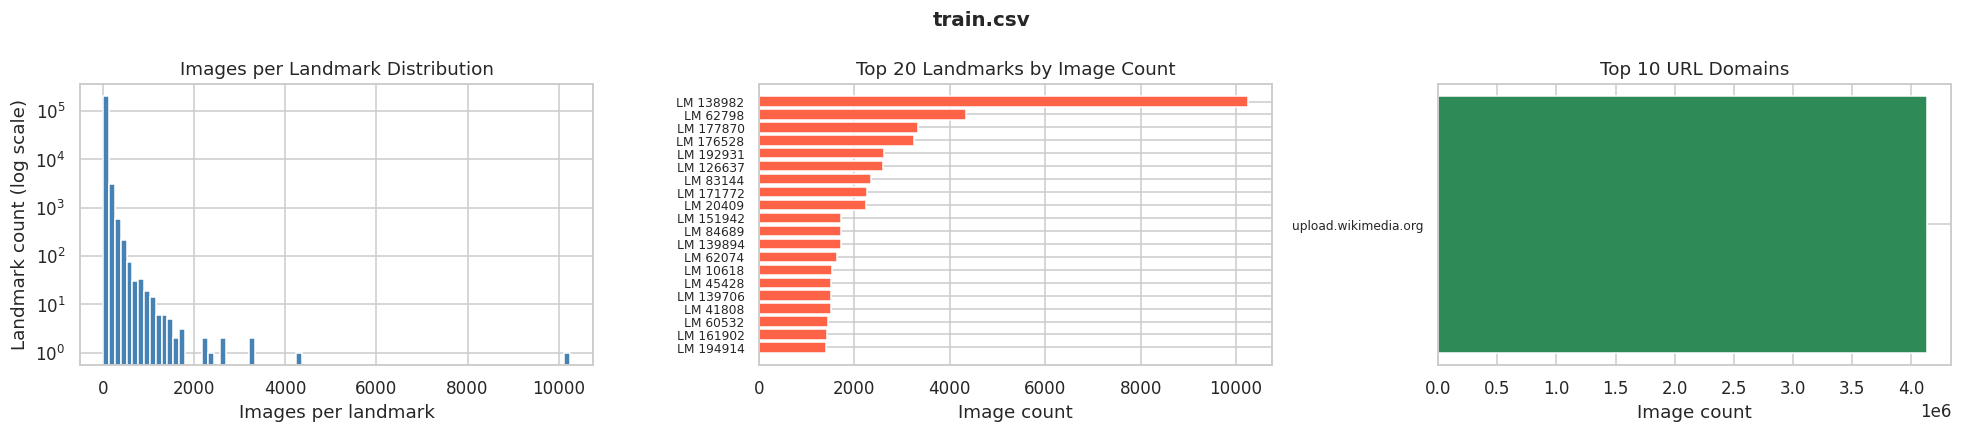

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('train.csv', fontsize=13, fontweight='bold')

# Distribution (log scale)
axes[0].hist(images_per_lm, bins=80, color='steelblue', edgecolor='white', log=True)
axes[0].set_xlabel('Images per landmark')
axes[0].set_ylabel('Landmark count (log scale)')
axes[0].set_title('Images per Landmark Distribution')

# Top 20 landmarks
top20 = images_per_lm.nlargest(20).sort_values()
axes[1].barh(range(20), top20.values, color='tomato', edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'LM {i}' for i in top20.index], fontsize=8)
axes[1].set_xlabel('Image count')
axes[1].set_title('Top 20 Landmarks by Image Count')

# URL domains
top_domains = domain_counts.head(10).sort_values()
axes[2].barh(range(len(top_domains)), top_domains.values, color='seagreen', edgecolor='white')
axes[2].set_yticks(range(len(top_domains)))
axes[2].set_yticklabels(top_domains.index, fontsize=8)
axes[2].set_xlabel('Image count')
axes[2].set_title('Top 10 URL Domains')

plt.tight_layout()
plt.show()

## Section 4 — train_clean.csv

Curated subset with reliably labeled images (team smlyaka). Each row is one landmark with a space-separated list of clean image IDs.

**Join key**: expand `images` column → individual image IDs → match to `id` in `train.csv`.

In [6]:
print('--- train_clean.csv ---')
display(clean_raw.head(5))

# Build set of clean image IDs
clean_image_ids = set()
for row_images in clean_raw['images']:
    clean_image_ids.update(str(row_images).split())

images_per_lm_clean = clean_raw['images'].str.split().apply(len)

n_clean_landmarks = len(clean_raw)
n_clean_images    = len(clean_image_ids)
print(f'\nLandmarks in clean set : {n_clean_landmarks:,}')
print(f'Unique image IDs       : {n_clean_images:,}')
print(f'Coverage of train.csv  : {n_clean_images / len(train) * 100:.1f}% of all images')
print(f'Landmark coverage      : {n_clean_landmarks / train["landmark_id"].nunique() * 100:.1f}% of all landmarks')
print(f'\nImages per landmark (clean set):')
print(images_per_lm_clean.describe().round(1).to_string())

--- train_clean.csv ---


,landmark_id,images
0,1,17660ef415d37059 92b6290d571448f6 cd41bf948edc0340 fb09f1e98c6d2f70
1,7,25c9dfc7ea69838d 28b13f94a6f1f3c1 307d6584f473ba35 4a7ba9eb16d51bc4 597353df...
2,9,0193b65bb58d2c77 1a30a51a287ecf69 1f4e8ab1f1b2321c 28267d88d4d9ea30 294c5690...
3,11,1a6cb1deed46bb17 1cc2c8fbc83e1a0c 2361b8da868c9113 32652480a7d99c5e 34533ce2...
4,12,0a199c97c382b1ff 1492a5d344495391 290097bd36a6b01d 2b87d221476447d2 2d685b12...



Landmarks in clean set : 81,313
Unique image IDs       : 1,580,470
Coverage of train.csv  : 38.2% of all images
Landmark coverage      : 40.0% of all landmarks

Images per landmark (clean set):
count    81313.0
mean        19.4
std         42.9
min          2.0
25%          5.0
50%          9.0
75%         20.0
max       6272.0


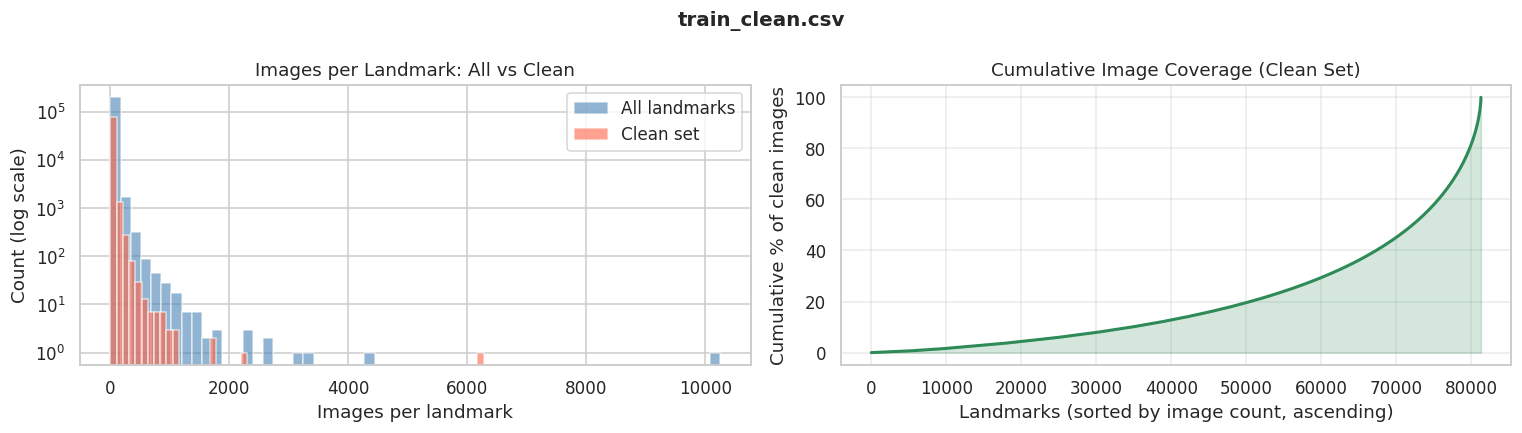

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('train_clean.csv', fontsize=13, fontweight='bold')

# All vs clean comparison (log scale)
axes[0].hist(images_per_lm,       bins=60, alpha=0.6, color='steelblue', label='All landmarks', log=True)
axes[0].hist(images_per_lm_clean, bins=60, alpha=0.6, color='tomato',    label='Clean set',     log=True)
axes[0].set_xlabel('Images per landmark')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Images per Landmark: All vs Clean')
axes[0].legend()

# Cumulative image coverage within clean set
sorted_clean = np.sort(images_per_lm_clean.values)
cumulative   = np.cumsum(sorted_clean)
axes[1].plot(range(len(cumulative)), cumulative / cumulative[-1] * 100, color='seagreen', linewidth=2)
axes[1].fill_between(range(len(cumulative)), cumulative / cumulative[-1] * 100, alpha=0.2, color='seagreen')
axes[1].set_xlabel('Landmarks (sorted by image count, ascending)')
axes[1].set_ylabel('Cumulative % of clean images')
axes[1].set_title('Cumulative Image Coverage (Clean Set)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Section 5 — train_attribution.csv

Attribution metadata per image: Wikimedia license type, author, and image title.

**Join key**: `id` (image ID) → matches `id` in `train.csv`.

In [8]:
print('--- train_attribution.csv ---')
display(attrib.head(5))

print(f'\nNull values per column (%):')
null_pct = attrib.isnull().mean() * 100
print(null_pct.round(2).to_string())

license_counts = attrib['license'].value_counts()
top_authors    = attrib['author'].value_counts().head(15)

print(f'\nUnique licenses : {attrib["license"].nunique()}')
print(f'Unique authors  : {attrib["author"].nunique():,}')
print(f'\nTop 10 licenses:')
print(license_counts.head(10).to_string())

--- train_attribution.csv ---


,id,url,author,license,title
0,6e158a47eb2ca3f6,http://commons.wikimedia.org/wiki/File:Observatoriet_v%C3%A4derkammer_2013a.jpg,Holger.Ellgaard,CC BY-SA 3.0(http://creativecommons.org/licenses/by-sa/3.0),File:Observatoriet väderkammer 2013a.jpg
1,202cd79556f30760,http://commons.wikimedia.org/wiki/File:Ecosse200996-1.jpg,LeCardinal,CC-BY-SA-3.0(http://creativecommons.org/licenses/by-sa/3.0),File:Ecosse200996-1.jpg
2,3ad87684c99c06e1,http://commons.wikimedia.org/wiki/File:Pirmasens_Dynamikum.jpg,LoKiLeCh,GFDL(http://www.gnu.org/copyleft/fdl.html)/CC-BY-SA-3.0-2.5-2.0-1.0(http://c...,File:Pirmasens Dynamikum.jpg
3,e7f70e9c61e66af3,http://commons.wikimedia.org/wiki/File:Occidental_Vertical.jpg,Andrés Osorio,CC BY 2.0(http://creativecommons.org/licenses/by/2.0),File:Occidental Vertical.jpg
4,4072182eddd0100e,http://commons.wikimedia.org/wiki/File:Looking_downstream_from_the_footbridg...,Stephen Whittaker and Katharine Oakeshott,CC BY-SA 2.0(https://creativecommons.org/licenses/by-sa/2.0),File:Looking downstream from the footbridge over the Severn - geograph.org.u...



Null values per column (%):
id         0.0
url        0.0
author     1.0
license    0.0
title      0.0

Unique licenses : 2023
Unique authors  : 284,838

Top 10 licenses:
license
CC BY-SA 4.0(https://creativecommons.org/licenses/by-sa/4.0)                                              647825
CC BY-SA 3.0(http://creativecommons.org/licenses/by-sa/3.0)                                               597225
CC BY-SA 4.0(http://creativecommons.org/licenses/by-sa/4.0)                                               572795
CC BY-SA 2.0(https://creativecommons.org/licenses/by-sa/2.0)                                              369289
CC BY-SA 3.0(https://creativecommons.org/licenses/by-sa/3.0)                                              330060
CC BY 2.0(http://creativecommons.org/licenses/by/2.0)                                                     235172
CC BY 3.0(http://creativecommons.org/licenses/by/3.0)                                                     177432
CC BY 2.0(https://creativecom

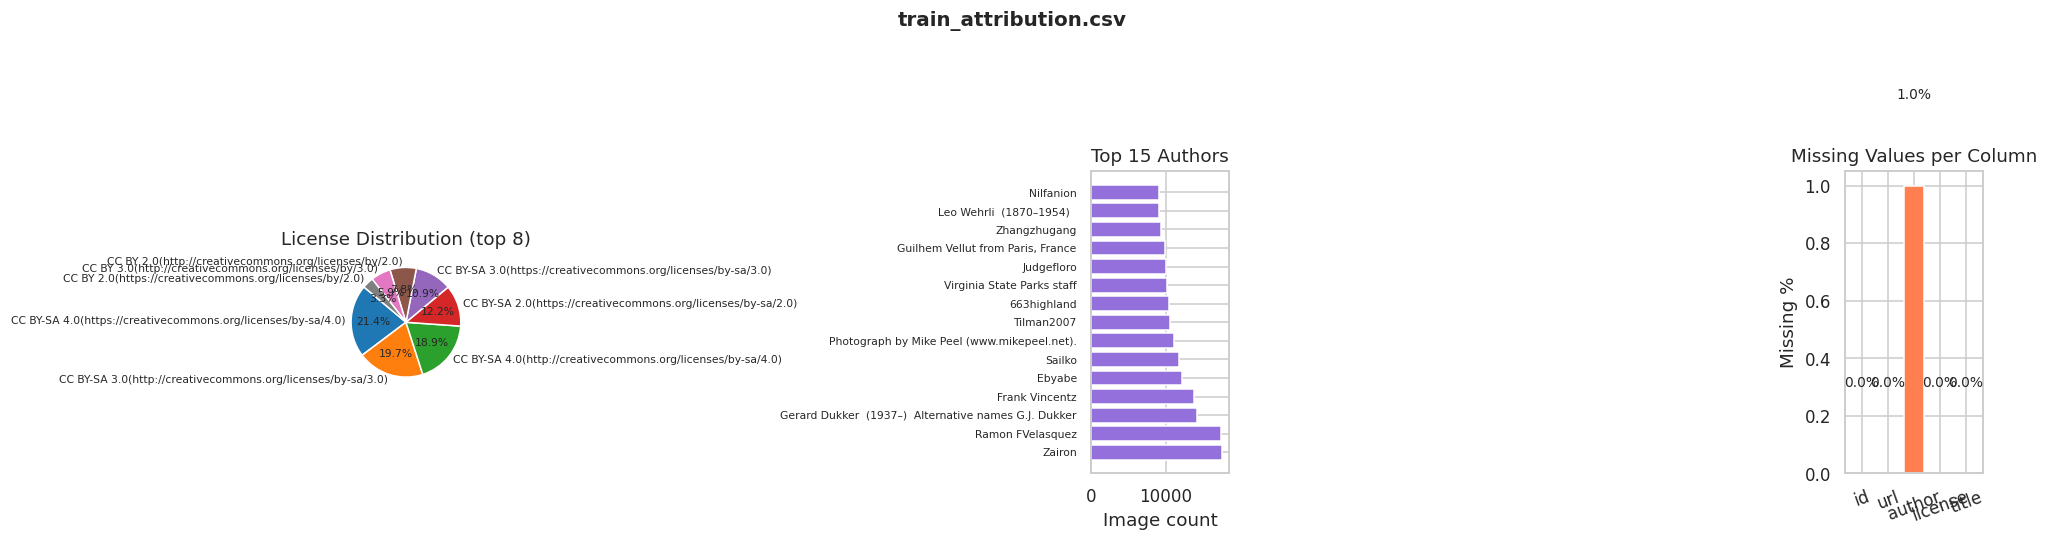

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('train_attribution.csv', fontsize=13, fontweight='bold')

# License pie (top 8)
top8_lic = license_counts.head(8)
wedges, texts, autotexts = axes[0].pie(
    top8_lic.values, labels=top8_lic.index, autopct='%1.1f%%',
    startangle=140, textprops={'fontsize': 7}
)
axes[0].set_title('License Distribution (top 8)')

# Top 15 authors
axes[1].barh(range(len(top_authors)), top_authors.values, color='mediumpurple', edgecolor='white')
axes[1].set_yticks(range(len(top_authors)))
axes[1].set_yticklabels(top_authors.index, fontsize=7)
axes[1].set_xlabel('Image count')
axes[1].set_title('Top 15 Authors')

# Missing values
axes[2].bar(null_pct.index, null_pct.values, color='coral', edgecolor='white')
axes[2].set_ylabel('Missing %')
axes[2].set_title('Missing Values per Column')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(null_pct.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Section 6 — train_label_to_category.csv

Maps each landmark to its Wikimedia Commons category URL. One row per landmark.

**Join key**: `landmark_id` → matches `landmark_id` in `train.csv`.

In [10]:
print('--- train_label_to_category.csv ---')
display(category.head(5))

# Extract readable category name from Wikimedia URL
category['category_name'] = (
    category['category']
    .str.extract(r'Category:(.+)$', expand=False)
    .str.replace('_', ' ', regex=False)
)

# Coverage check
train_landmarks = set(train['landmark_id'])
cat_landmarks   = set(category['landmark_id'])
matched         = cat_landmarks & train_landmarks

print(f'\nLandmarks with category entry : {len(category):,}')
print(f'Unique categories             : {category["category"].nunique():,}')
print(f'Coverage of train.csv         : {len(matched):,} / {len(train_landmarks):,} ({len(matched)/len(train_landmarks)*100:.1f}%)')

# Wikimedia base domains
category['wiki_base'] = category['category'].str.extract(r'(https?://[^/]+)', expand=False)
print(f'\nWikimedia base domains:')
print(category['wiki_base'].value_counts().to_string())

print(f'\nSample category names:')
print(category['category_name'].dropna().sample(10, random_state=42).to_string())

--- train_label_to_category.csv ---


,landmark_id,category
0,0,http://commons.wikimedia.org/wiki/Category:Happy_Valley_Racecourse
1,1,http://commons.wikimedia.org/wiki/Category:Luitpoldpark_in_Munich
2,2,http://commons.wikimedia.org/wiki/Category:Grand_Ventron
3,3,"http://commons.wikimedia.org/wiki/Category:Tweed_Heads,_New_South_Wales"
4,4,http://commons.wikimedia.org/wiki/Category:Santa_Maria_Immacolata_della_Conc...



Landmarks with category entry : 203,094
Unique categories             : 203,094
Coverage of train.csv         : 203,094 / 203,094 (100.0%)

Wikimedia base domains:
wiki_base
http://commons.wikimedia.org    203094

Sample category names:
199310                 Hotel Roosevelt, Hollywood
201682                           Mercado del Este
185820                             Maxberg Museum
112149                   Hilbre Island Lighthouse
26453                St. Lorenz, Oberf%C3%B6hring
16529                     Muur van Geraardsbergen
81908     St. Peter und Paul (Obergessertshausen)
115853                  Mystic Seaport Lighthouse
53083                    Market hall in Bydgoszcz
88026                              Tambo Colorado


## Section 7 — train_label_to_hierarchical.csv

Extended label metadata per landmark: Wikimedia category, **supercategory** (broad type), **hierarchical label** (path string), and whether the landmark is **natural or human-made**.

**Join key**: `landmark_id` → matches `landmark_id` in `train.csv`.

In [11]:
print('--- train_label_to_hierarchical.csv ---')
display(hierarchical.head(5))
print(f'\nColumns: {list(hierarchical.columns)}')

nat_hm   = hierarchical['natural_or_human_made'].value_counts()
supercat = hierarchical['supercategory'].value_counts()
hierarchical['label_depth'] = hierarchical['hierarchical_label'].str.count('>') + 1

print(f'\nNatural vs Human-made (landmarks):')
print(nat_hm.to_string())
print(f'\nTop 20 Supercategories:')
print(supercat.head(20).to_string())
print(f'\nHierarchical label depth:')
print(hierarchical['label_depth'].describe().round(1).to_string())

--- train_label_to_hierarchical.csv ---


,landmark_id,category,supercategory,hierarchical_label,natural_or_human_made
0,0,http://commons.wikimedia.org/wiki/Category:Happy_Valley_Racecourse,horse racing venue,sports venue,human-made
1,1,http://commons.wikimedia.org/wiki/Category:Luitpoldpark_in_Munich,park,parks,natural
2,2,http://commons.wikimedia.org/wiki/Category:Grand_Ventron,mountain,mountain,natural
3,5,http://commons.wikimedia.org/wiki/Category:Lakeside_International_Raceway,motorsport racing track,road,human-made
4,7,"http://commons.wikimedia.org/wiki/Category:Sparkassen-Arena,_G%C3%B6ttingen",multi-purpose hall,NaN,NaN



Columns: ['landmark_id', 'category', 'supercategory', 'hierarchical_label', 'natural_or_human_made']

Natural vs Human-made (landmarks):
natural_or_human_made
human-made    76810
natural       28400

Top 20 Supercategories:
supercategory
church building            19832
mountain                    6286
museum                      3816
castle                      3541
lake                        2767
building                    2461
park                        1985
château                     1756
lighthouse                  1587
cemetery                    1489
architectural structure     1449
island                      1429
art museum                  1364
house                       1287
river                       1194
monastery                   1107
skyscraper                  1057
archaeological site         1031
palace                       990
parish church                983

Hierarchical label depth:
count    105210.0
mean          1.0
std           0.0
min           1.0
25

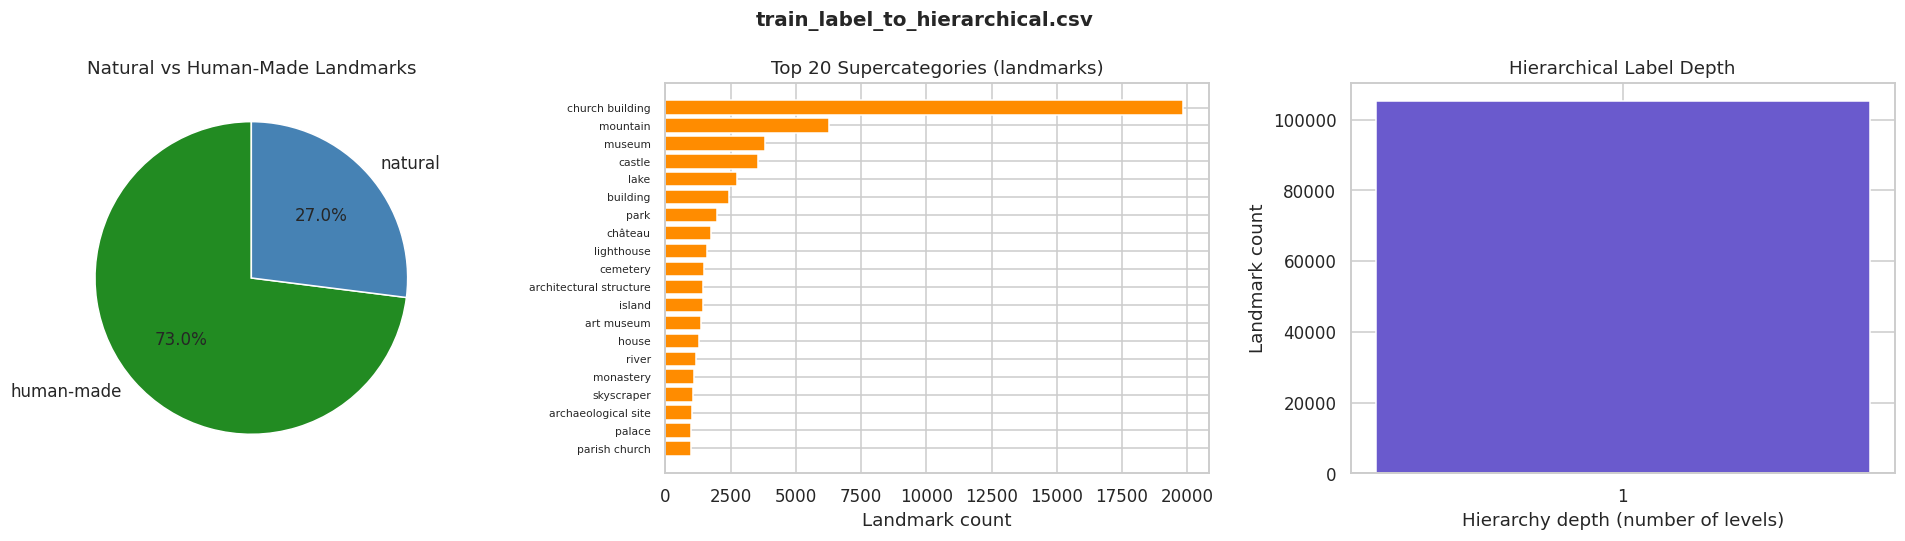

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('train_label_to_hierarchical.csv', fontsize=13, fontweight='bold')

# Natural vs human-made pie
axes[0].pie(
    nat_hm.values, labels=nat_hm.index, autopct='%1.1f%%',
    colors=['forestgreen', 'steelblue'], startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('Natural vs Human-Made Landmarks')

# Top 20 supercategories
top_sc = supercat.head(20).sort_values()
axes[1].barh(range(len(top_sc)), top_sc.values, color='darkorange', edgecolor='white')
axes[1].set_yticks(range(len(top_sc)))
axes[1].set_yticklabels(top_sc.index, fontsize=7)
axes[1].set_xlabel('Landmark count')
axes[1].set_title('Top 20 Supercategories (landmarks)')

# Label depth distribution
max_depth = int(hierarchical['label_depth'].max())
axes[2].hist(
    hierarchical['label_depth'].dropna(),
    bins=range(1, max_depth + 2),
    color='slateblue', edgecolor='white', align='left'
)
axes[2].set_xlabel('Hierarchy depth (number of levels)')
axes[2].set_ylabel('Landmark count')
axes[2].set_title('Hierarchical Label Depth')
axes[2].set_xticks(range(1, max_depth + 1))

plt.tight_layout()
plt.show()

## Section 8 — Merged Analysis & Relationships

```
Join map:

  image id ──> train.csv          (id, url, landmark_id)
  image id ──> train_attribution  (license, author, title)
  image id ──> [clean flag]       (is_clean, from train_clean.csv)
                    │
              landmark_id ──> train_label_to_category    (category URL)
              landmark_id ──> train_label_to_hierarchical (supercategory,
                                                            natural_or_human_made,
                                                            hierarchical_label)
```

Builds one master row per image with all joined fields.

In [13]:
print('Building master dataframe ...')

attrib_slim = attrib[['id', 'license', 'author']].copy()
hier_slim   = hierarchical[['landmark_id', 'supercategory', 'natural_or_human_made', 'hierarchical_label']].copy()
cat_slim    = category[['landmark_id', 'category_name']].copy()

master = (
    train[['id', 'landmark_id']]
    .merge(attrib_slim, on='id',          how='left')
    .merge(hier_slim,   on='landmark_id', how='left')
    .merge(cat_slim,    on='landmark_id', how='left')
)
master['is_clean'] = master['id'].isin(clean_image_ids)

print(f'Master shape  : {master.shape[0]:,} rows x {master.shape[1]} columns')
print(f'Columns       : {list(master.columns)}')
display(master.head(5))

print('\n' + '='*55)
print('MERGE COVERAGE')
print('='*55)
for col in ['license', 'author', 'supercategory', 'natural_or_human_made', 'category_name']:
    n     = master[col].notna().sum()
    total = len(master)
    print(f'  {col:<25}: {n:>10,} / {total:,}  ({n/total*100:.1f}%)')
n_clean = master['is_clean'].sum()
print(f'  {"is_clean":<25}: {n_clean:>10,} / {len(master):,}  ({n_clean/len(master)*100:.1f}%)')

Building master dataframe ...
Master shape  : 4,132,914 rows x 9 columns
Columns       : ['id', 'landmark_id', 'license', 'author', 'supercategory', 'natural_or_human_made', 'hierarchical_label', 'category_name', 'is_clean']


,id,landmark_id,license,author,supercategory,natural_or_human_made,hierarchical_label,category_name,is_clean
0,6e158a47eb2ca3f6,142820,CC BY-SA 3.0(http://creativecommons.org/licenses/by-sa/3.0),Holger.Ellgaard,NaN,NaN,NaN,Stockholms gamla observatorium,False
1,202cd79556f30760,104169,CC-BY-SA-3.0(http://creativecommons.org/licenses/by-sa/3.0),LeCardinal,castle,human-made,castle / fort,Stirling Castle,True
2,3ad87684c99c06e1,37914,GFDL(http://www.gnu.org/copyleft/fdl.html)/CC-BY-SA-3.0-2.5-2.0-1.0(http://c...,LoKiLeCh,NaN,NaN,NaN,Dynamikum,False
3,e7f70e9c61e66af3,102140,CC BY 2.0(http://creativecommons.org/licenses/by/2.0),Andrés Osorio,NaN,NaN,NaN,Estadio Deportivo Cali,True
4,4072182eddd0100e,2474,CC BY-SA 2.0(https://creativecommons.org/licenses/by-sa/2.0),Stephen Whittaker and Katharine Oakeshott,river,natural,river,River Severn,False



MERGE COVERAGE
  license                  :  4,132,914 / 4,132,914  (100.0%)
  author                   :  4,091,556 / 4,132,914  (99.0%)
  supercategory            :  2,935,190 / 4,132,914  (71.0%)
  natural_or_human_made    :  2,416,940 / 4,132,914  (58.5%)
  category_name            :  4,132,914 / 4,132,914  (100.0%)
  is_clean                 :  1,580,470 / 4,132,914  (38.2%)


In [14]:
# Summary table: per-supercategory stats
sc_summary = (
    master.dropna(subset=['supercategory'])
    .groupby('supercategory')
    .agg(
        images        =('id',             'count'),
        landmarks     =('landmark_id',     'nunique'),
        clean_images  =('is_clean',        'sum'),
    )
    .assign(clean_pct=lambda d: (d['clean_images'] / d['images'] * 100).round(1))
    .sort_values('images', ascending=False)
)

print('Per-supercategory summary (top 20 by image count):')
display(sc_summary.head(20))

print(f'\nNatural vs Human-made image counts:')
print(master.groupby('natural_or_human_made').size().to_string())

Per-supercategory summary (top 20 by image count):


,images,landmarks,clean_images,clean_pct
supercategory,,,,
church building,313593,19832,170051,54.2
castle,105391,3541,59830,56.8
mountain,96918,6286,26097,26.9
museum,83546,3816,22655,27.1
park,56234,1985,10408,18.5
château,50485,1756,29127,57.7
cemetery,50052,1489,11193,22.4
lake,50009,2767,20224,40.4
monastery,43845,1107,24749,56.4



Natural vs Human-made image counts:
natural_or_human_made
human-made    1721747
natural        695193


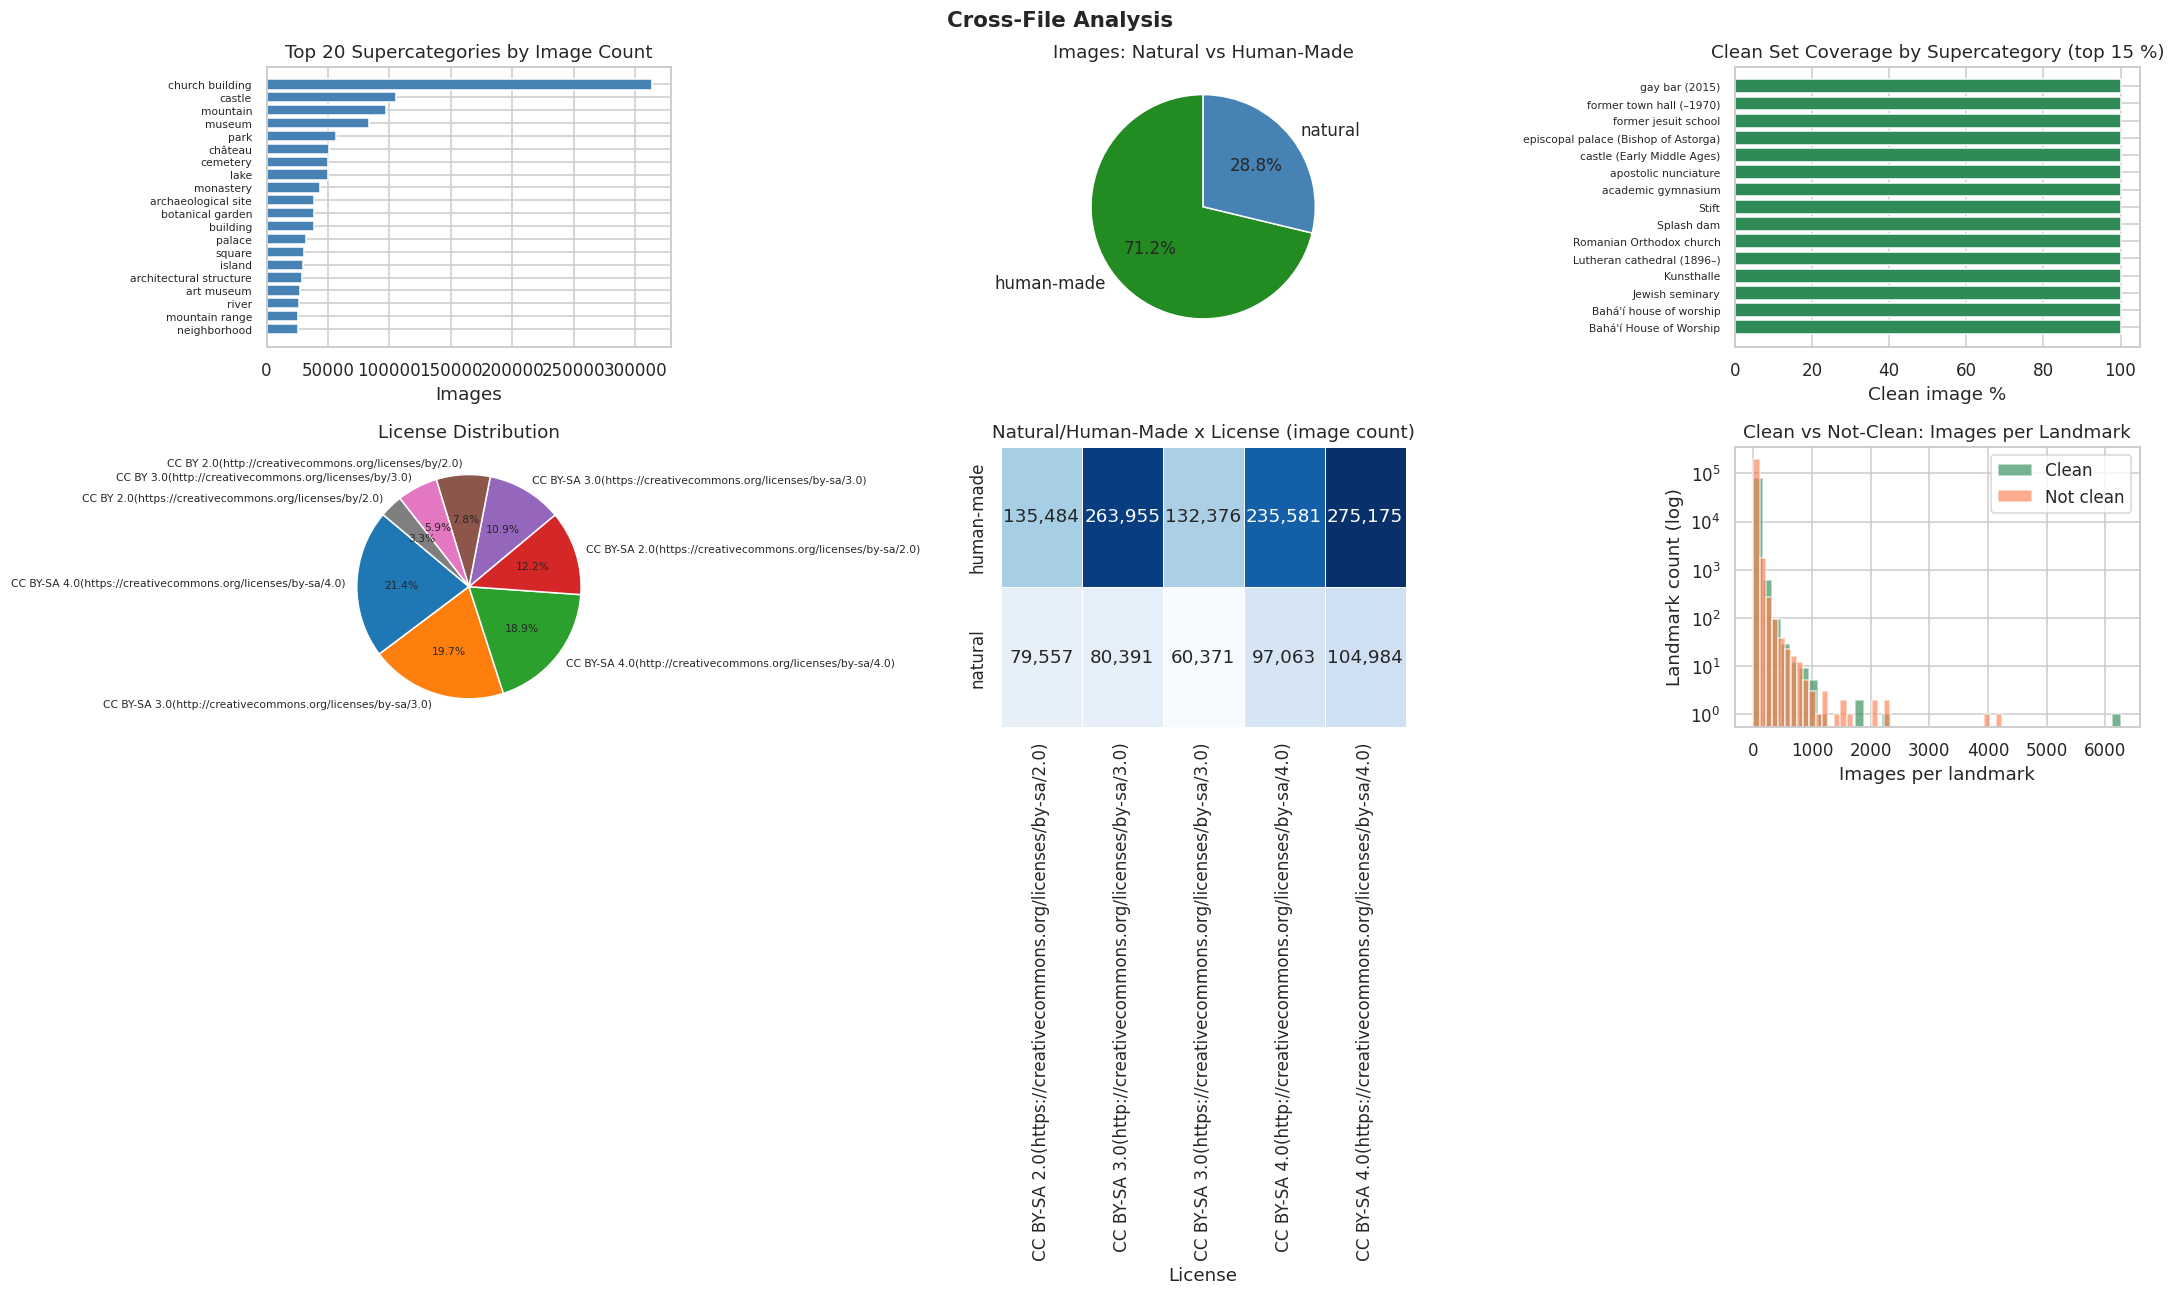

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Cross-File Analysis', fontsize=14, fontweight='bold')

# 1. Images per supercategory (top 20)
sc_images = master.groupby('supercategory').size().nlargest(20).sort_values()
axes[0, 0].barh(range(len(sc_images)), sc_images.values, color='steelblue', edgecolor='white')
axes[0, 0].set_yticks(range(len(sc_images)))
axes[0, 0].set_yticklabels(sc_images.index, fontsize=7)
axes[0, 0].set_xlabel('Images')
axes[0, 0].set_title('Top 20 Supercategories by Image Count')

# 2. Natural vs human-made image count (pie)
nat_img = master.groupby('natural_or_human_made').size().dropna()
axes[0, 1].pie(
    nat_img.values, labels=nat_img.index, autopct='%1.1f%%',
    colors=['forestgreen', 'steelblue'], startangle=90,
    textprops={'fontsize': 11}
)
axes[0, 1].set_title('Images: Natural vs Human-Made')

# 3. Clean set coverage by supercategory (top 15 by coverage %)
sc_clean_pct = (
    master.dropna(subset=['supercategory'])
    .groupby('supercategory')['is_clean']
    .mean() * 100
).nlargest(15).sort_values()
axes[0, 2].barh(range(len(sc_clean_pct)), sc_clean_pct.values, color='seagreen', edgecolor='white')
axes[0, 2].set_yticks(range(len(sc_clean_pct)))
axes[0, 2].set_yticklabels(sc_clean_pct.index, fontsize=7)
axes[0, 2].set_xlabel('Clean image %')
axes[0, 2].set_title('Clean Set Coverage by Supercategory (top 15 %)')

# 4. License distribution (pie, top 8)
lic = master['license'].value_counts().head(8)
axes[1, 0].pie(
    lic.values, labels=lic.index, autopct='%1.1f%%',
    startangle=140, textprops={'fontsize': 7}
)
axes[1, 0].set_title('License Distribution')

# 5. Natural/Human-made x top-5 licenses heatmap
top5_lic = master['license'].value_counts().head(5).index
hm_data  = (
    master[master['license'].isin(top5_lic)]
    .groupby(['natural_or_human_made', 'license'])
    .size()
    .unstack(fill_value=0)
)
sns.heatmap(
    hm_data, annot=True, fmt=',d', cmap='Blues',
    ax=axes[1, 1], cbar=False, linewidths=0.5
)
axes[1, 1].set_title('Natural/Human-Made x License (image count)')
axes[1, 1].set_xlabel('License')
axes[1, 1].set_ylabel('')

# 6. Clean vs not-clean: images per landmark
clean_per_lm    = master[master['is_clean']].groupby('landmark_id').size()
notclean_per_lm = master[~master['is_clean']].groupby('landmark_id').size()
axes[1, 2].hist(clean_per_lm,    bins=40, alpha=0.65, color='seagreen', label='Clean',     log=True)
axes[1, 2].hist(notclean_per_lm, bins=40, alpha=0.65, color='coral',    label='Not clean', log=True)
axes[1, 2].set_xlabel('Images per landmark')
axes[1, 2].set_ylabel('Landmark count (log)')
axes[1, 2].set_title('Clean vs Not-Clean: Images per Landmark')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [16]:
# ---- Final relationship summary ----
print('='*60)
print('WHAT IS RELATED TO WHAT')
print('='*60)

print('''
image id  -->  train.csv            (landmark_id, url)
          -->  train_attribution    (license, author, title)
          -->  [is_clean flag]      built from train_clean.csv

landmark_id  -->  train_label_to_category      (Wikimedia category URL)
             -->  train_label_to_hierarchical  (supercategory,
                                                hierarchical_label,
                                                natural_or_human_made)
''')

print('Key numbers:')
print(f'  {len(train):>10,}  total images (train.csv)')
print(f'  {len(clean_image_ids):>10,}  images with reliable labels (train_clean.csv)')
print(f'  {master["license"].notna().sum():>10,}  images with license info  (train_attribution.csv)')
print(f'  {train["landmark_id"].nunique():>10,}  unique landmarks')
print(f'  {len(category):>10,}  landmarks with Wikimedia category')
print(f'  {len(hierarchical):>10,}  landmarks with hierarchy & type')
print(f'  {master["supercategory"].notna().sum():>10,}  images with supercategory (via landmark join)')
print(f'  {hierarchical["supercategory"].nunique():>10,}  distinct supercategories')
print(f'  {hierarchical["natural_or_human_made"].nunique():>10,}  natural/human-made values')

WHAT IS RELATED TO WHAT

image id  -->  train.csv            (landmark_id, url)
          -->  train_attribution    (license, author, title)
          -->  [is_clean flag]      built from train_clean.csv

landmark_id  -->  train_label_to_category      (Wikimedia category URL)
             -->  train_label_to_hierarchical  (supercategory,
                                                hierarchical_label,
                                                natural_or_human_made)

Key numbers:
   4,132,914  total images (train.csv)
   1,580,470  images with reliable labels (train_clean.csv)
   4,132,914  images with license info  (train_attribution.csv)
     203,094  unique landmarks
     203,094  landmarks with Wikimedia category
     128,842  landmarks with hierarchy & type
   2,935,190  images with supercategory (via landmark join)
       5,543  distinct supercategories
           2  natural/human-made values
